In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def construct_image_cube(folder_name):
    folder_path = f'dss_dataset/ms_tif_images/{folder_name}'
    image_files = [f for f in os.listdir(folder_path) if f.endswith('.tif')]
    image_files = sorted(image_files)

    image_cube = np.empty((4, ), dtype=object)

    count = 0
    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED).astype(np.float64)
        image_cube[count] = image
        count += 1

    image_cube = np.stack(image_cube, axis=0)

    return image_cube


In [3]:
frag_name='198-006'
ir_path='dss_dataset/ir_images/4Q26-198-6.jpg'
color_path='dss_dataset/color_images/4Q26-198-6.jpg'


In [4]:
image_cube_124_001 = construct_image_cube(frag_name)

In [5]:
image_cube_124_001.shape

(4, 5412, 7216)

In [6]:
bar_mask_recto = np.zeros(image_cube_124_001.shape[1:], dtype=np.uint8)

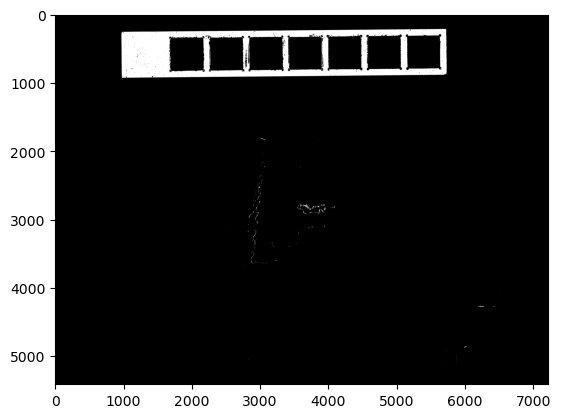

In [7]:
#colorbar
I1 = image_cube_124_001[1, :, :]
I0 = image_cube_124_001[0, :, :]

mask1 = I1-I0<600
mask2 = I1-I0>300
mask3 = I0<100
mask = mask1&mask2&mask3

colorbar = np.zeros_like(I0)
colorbar [mask] = 255
colorbar = np.uint8(colorbar)
plt.imshow(colorbar , cmap = 'gray')

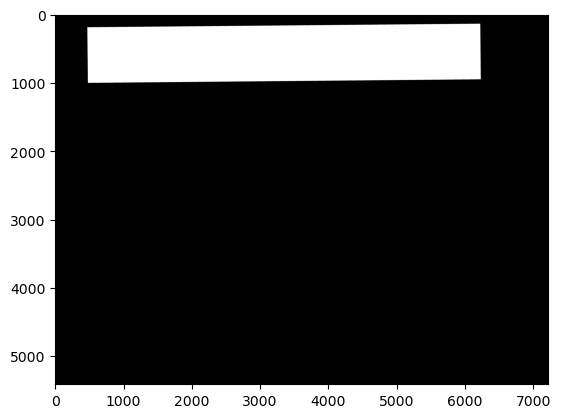

In [8]:

contours, _ = cv2.findContours(colorbar, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
rect = cv2.minAreaRect(largest_contour)
box = cv2.boxPoints(rect)
center = np.mean(box, axis=0)
box = box - center 
for i in range(len(box)):
    box[i] *= 1 + (500 / np.linalg.norm(box[i]))  # Scale points away from center
box = box + center 

box = np.intp(box)
cv2.drawContours(bar_mask_recto, [box], 0, (1), -1)

plt.imshow(bar_mask_recto, cmap='gray')


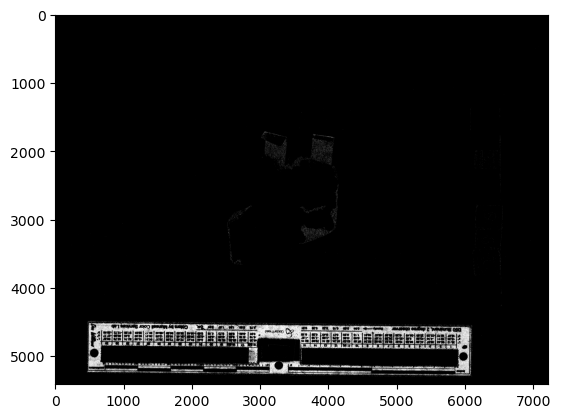

In [9]:
#metricbar
I1 = image_cube_124_001[1, :, :]*(1-bar_mask_recto)
I0 = image_cube_124_001[0, :, :]*(1-bar_mask_recto)

mask1 = I0>500
mask2 = I0<550
mask3 = I1-I0<80
mask = mask1 & mask2 & mask3

metricbar = np.zeros_like(I0)
metricbar [mask] = 255
metricbar = np.uint8(metricbar)
plt.imshow(metricbar , cmap = 'gray')

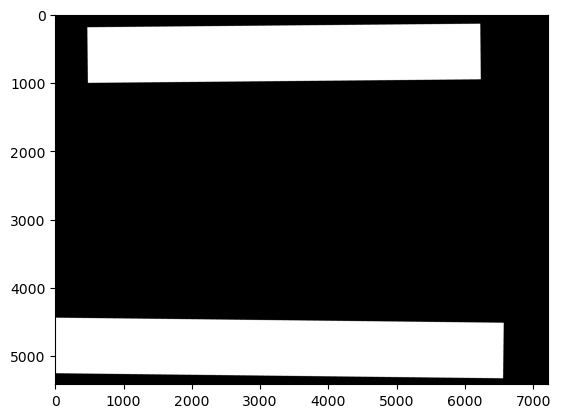

In [10]:

contours, _ = cv2.findContours(metricbar, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
rect = cv2.minAreaRect(largest_contour)
box = cv2.boxPoints(rect)
center = np.mean(box, axis=0)
box = box - center  
for i in range(len(box)):
    box[i] *= 1 + (500 / np.linalg.norm(box[i]))  # Scale points away from center
box = box + center 

box = np.intp(box)
cv2.drawContours(bar_mask_recto, [box], 0, (1), -1)

plt.imshow(bar_mask_recto, cmap='gray')


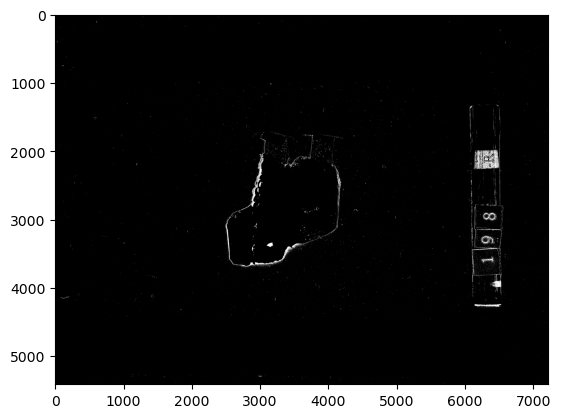

In [11]:
#codebar
I1 = image_cube_124_001[1, :, :]*(1-bar_mask_recto)
I0 = image_cube_124_001[0, :, :]*(1-bar_mask_recto)


mask1 = I1<300
mask2 = I1-I0<200
mask3 = I1-I0>50
mask4 = I1 > 1500
mask5 = I1 < 1800
mask6 = I1-I0 < 100

mask = (mask1&mask2&mask3)|(mask4 & mask5 & mask6)
codebar = np.zeros_like(I0)
codebar [mask] = 255
codebar = np.uint8(codebar)
plt.imshow(codebar , cmap = 'gray')

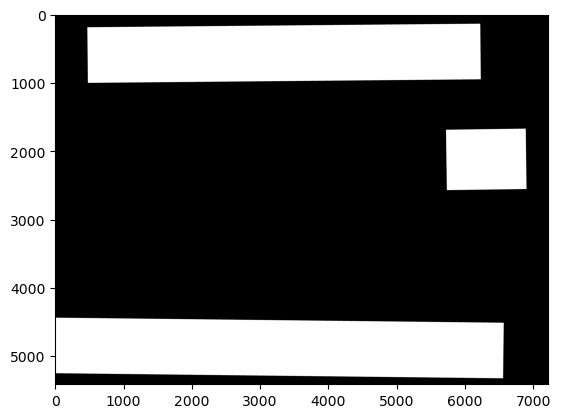

In [12]:

contours, _ = cv2.findContours(codebar, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
rect = cv2.minAreaRect(largest_contour)
box = cv2.boxPoints(rect)
center = np.mean(box, axis=0)
box = box - center  
for i in range(len(box)):
    box[i] *= 1 + (500 / np.linalg.norm(box[i]))  # Scale points away from center
box = box + center 

box = np.intp(box)
cv2.drawContours(bar_mask_recto, [box], 0, (1), -1)

plt.imshow(bar_mask_recto, cmap='gray')


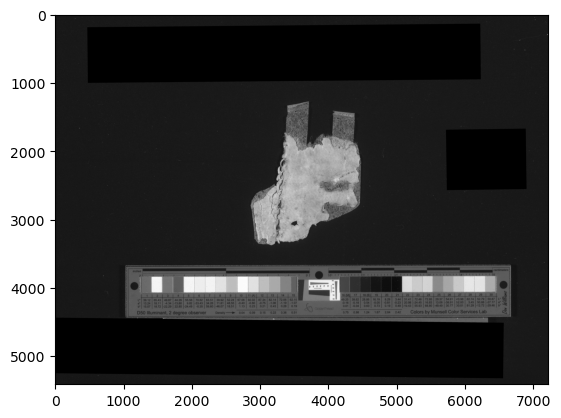

In [13]:
ir = cv2.imread(ir_path, 0)*(1-bar_mask_recto)
plt.imshow(ir, cmap='gray')

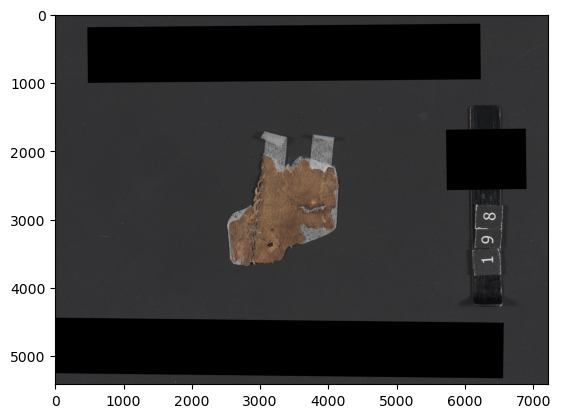

In [14]:
inv_bar_mask_recto=(1-bar_mask_recto)
expanded_mask = np.stack((inv_bar_mask_recto,)*3, axis=-1)
bgr_color = cv2.imread(color_path, 1)*expanded_mask
rgb_color = cv2.cvtColor(bgr_color, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_color)

In [15]:
import os
import json
from adiel_dss_segmentation.remove_jp_paper import remove_jp_paper
from adiel_dss_segmentation.cut_fragment import cut_fragment
from adiel_dss_segmentation.get_boundaries import get_boundaries
from  adiel_dss_segmentation.save_boundaries_to_json import display_json, save_boundaries_to_json


In [16]:
json_file = 'adiel_dss_segmentation/param_segmentation.json'
with open(json_file, mode='r') as fh:
    json_params = json.load(fh)

In [17]:
cut_frag=cut_fragment(bgr_color, **json_params)

cut_fragment done


In [18]:
cut_frag = cut_frag.astype(np.uint8)


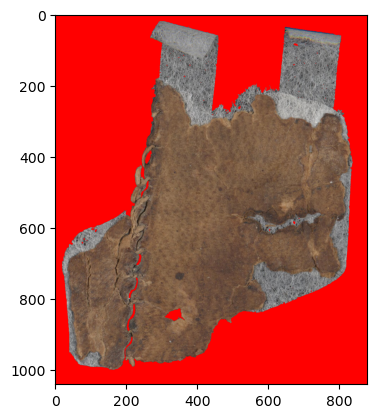

In [19]:
rgb_channels = cut_frag[:, :, :3] 
alpha_channel = cut_frag[:, :, 3]  

green_background = np.zeros_like(rgb_channels)
green_background[:, :, 2] = 255  
if alpha_channel.max() > 1:
    alpha_channel = alpha_channel / 255

composite_image = np.zeros_like(rgb_channels)
for i in range(3):  
    composite_image[:, :, i] = (alpha_channel * rgb_channels[:, :, i] +
                                (1 - alpha_channel) * green_background[:, :, i]).astype(np.uint8)

plt.imshow(composite_image[:,:,::-1])


In [20]:
removejp_frag=remove_jp_paper(bgr_color, **json_params)

/home/nachum/berat/anaconda3/envs/python39env/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


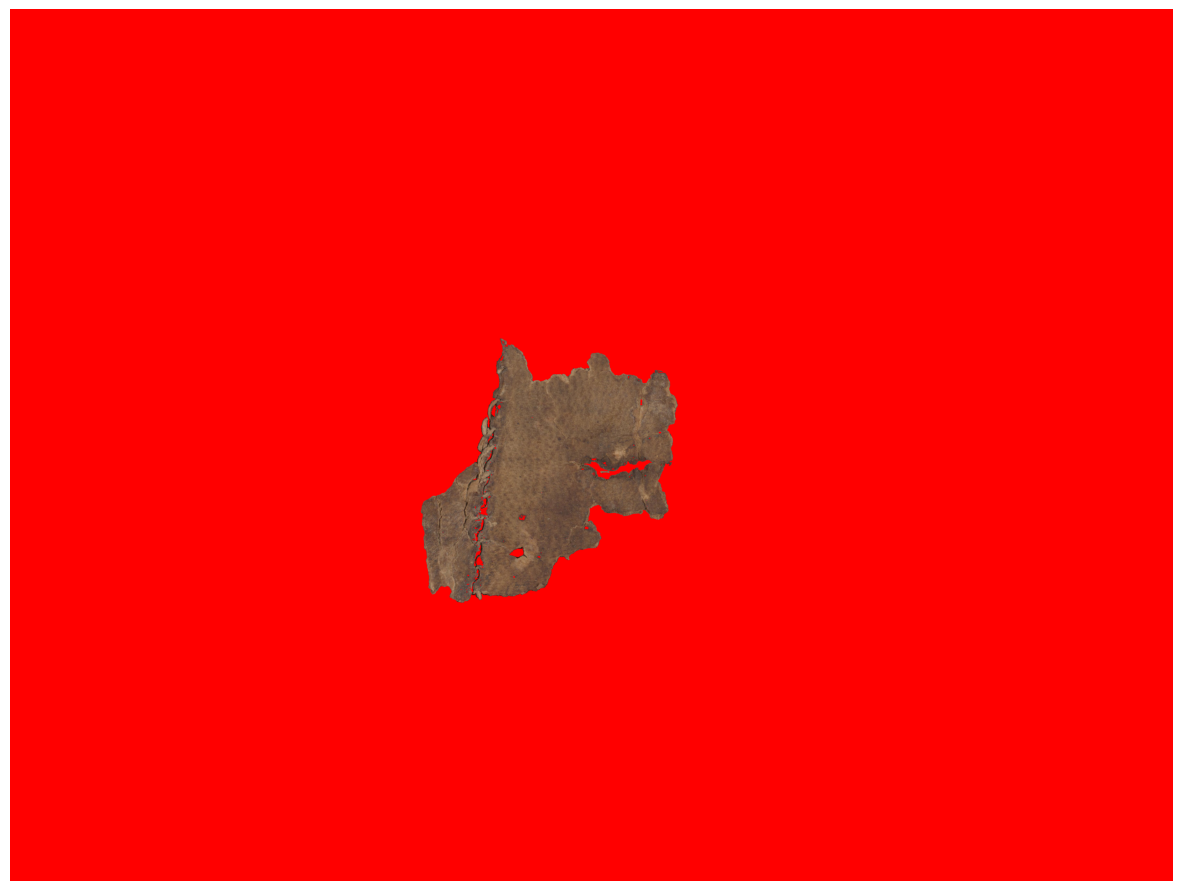

In [21]:
rgb_channels = removejp_frag[:, :, :3] 
alpha_channel = removejp_frag[:, :, 3]  

red_background = np.zeros_like(rgb_channels)
red_background[:, :, 2] = 255  
if alpha_channel.max() > 1:
    alpha_channel = alpha_channel / 255

composite_image = np.zeros_like(rgb_channels)
for i in range(3):  
    composite_image[:, :, i] = (alpha_channel * rgb_channels[:, :, i] +
                                (1 - alpha_channel) * red_background[:, :, i]).astype(np.uint8)


plt.figure(figsize=(15, 15))
plt.imshow(composite_image[:,:,::-1], cmap='gray')  
plt.axis('off')  
plt.show()

In [22]:
cv2.imwrite('adiel_segments/'+frag_name+'_redback.png',composite_image)

True

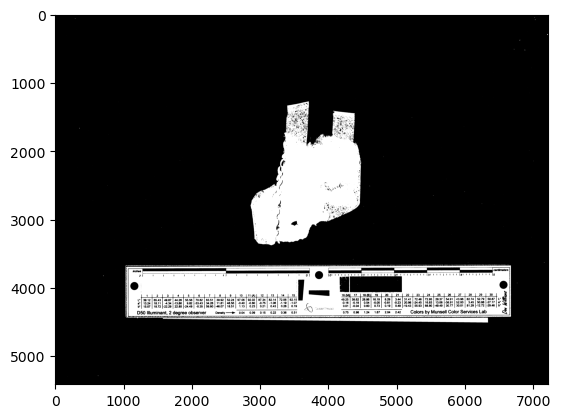

In [23]:
retval, otsu = cv2.threshold(ir, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsu,cmap='gray')

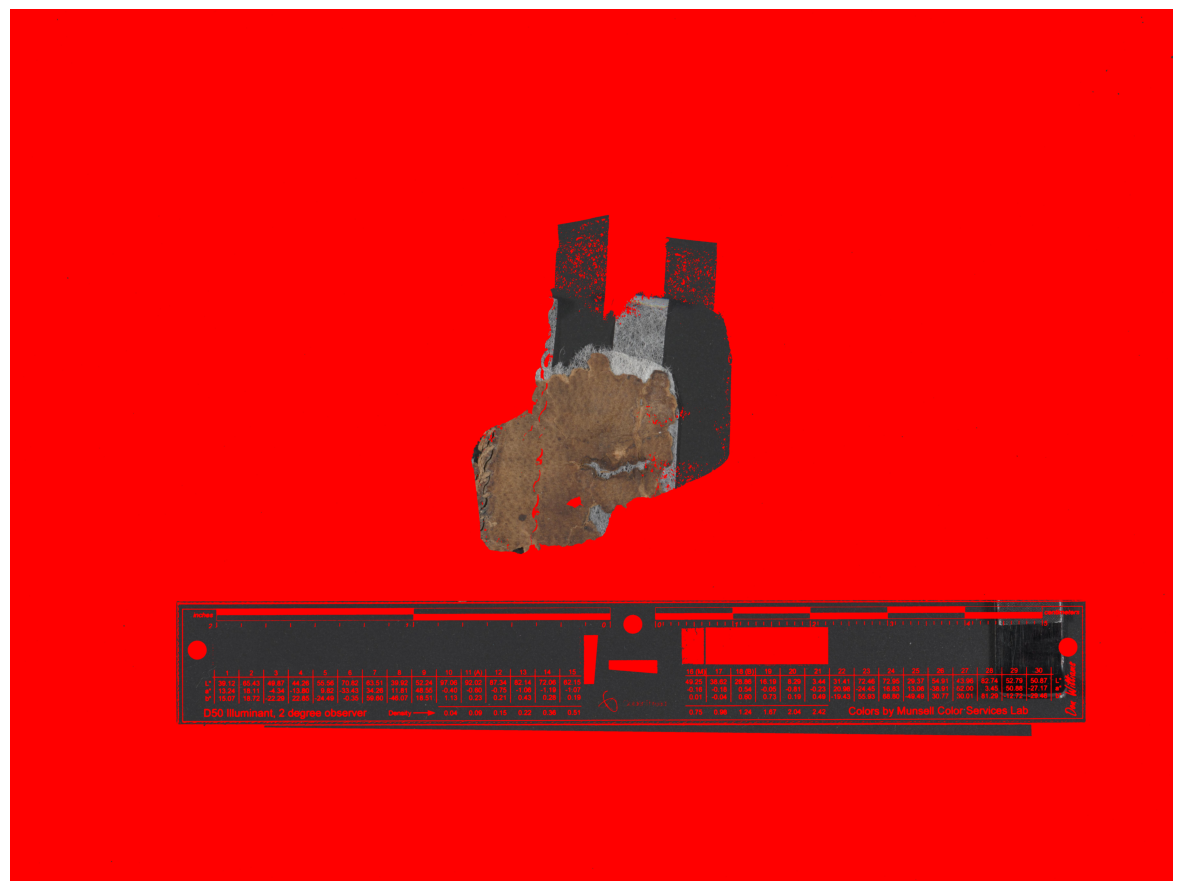

In [24]:
otsuredback=bgr_color.copy()

red_mask = otsu == 0
otsuredback[red_mask] = [0, 0, 255]  

plt.figure(figsize=(15, 15))
plt.imshow(otsuredback[:,:,::-1], cmap='gray')  
plt.axis('off')  
plt.show()


In [25]:
cv2.imwrite('otsu_segments/'+frag_name+'_redback.png',otsuredback)

True

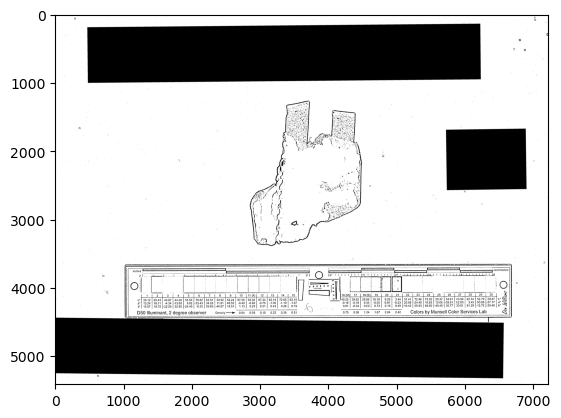

In [26]:
from skimage.filters import threshold_sauvola
import skimage.io

sauvola_thresh = threshold_sauvola(ir, window_size=25)
sau_image = ir > sauvola_thresh
sau_image=np.uint8(sau_image)*255
plt.imshow(sau_image,cmap='gray')

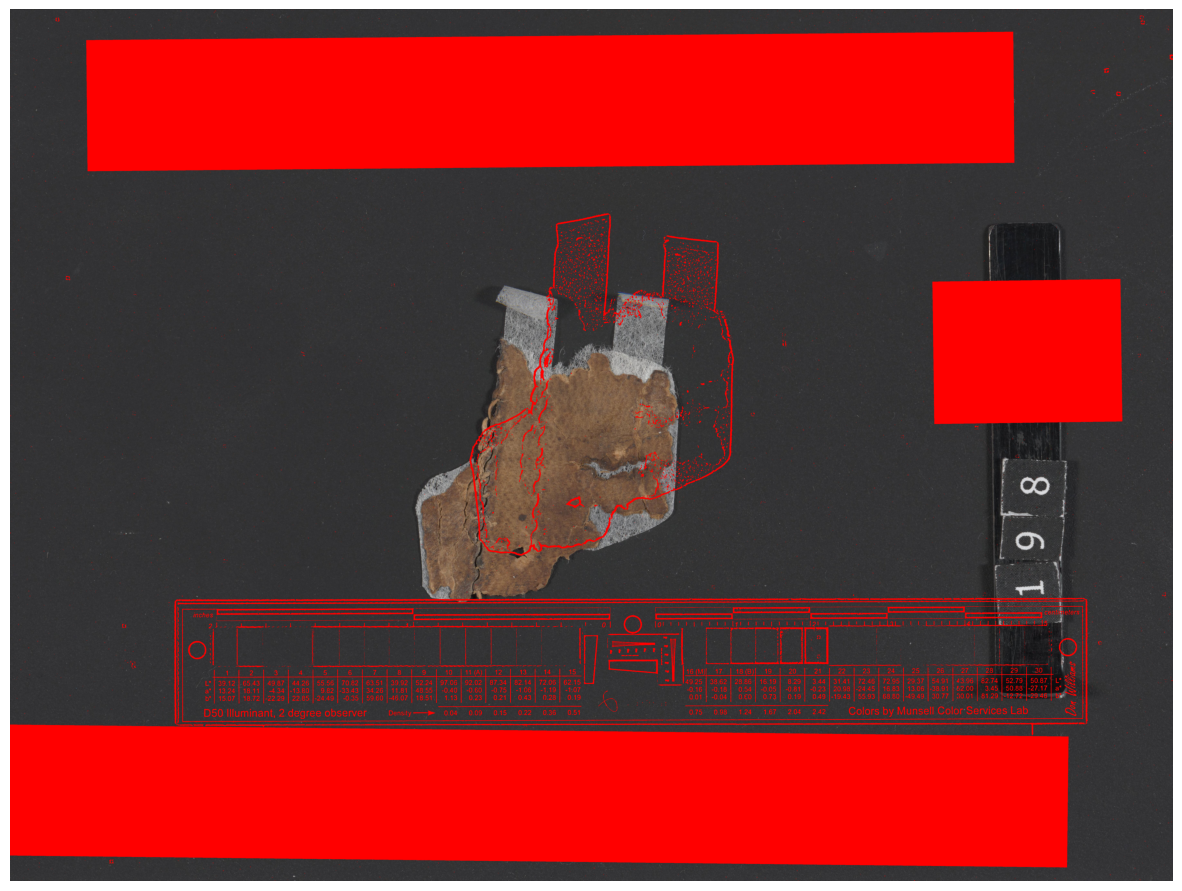

In [27]:
sauredback=bgr_color.copy()

red_mask = sau_image == 0
sauredback[red_mask] = [0, 0, 255]  

plt.figure(figsize=(15, 15))
plt.imshow(sauredback[:,:,::-1], cmap='gray')  
plt.axis('off')  
plt.show()

In [28]:
cv2.imwrite('sauvola_segments/'+frag_name+'_redback.png',sauredback)

True